# 1. Introduction

## Objective

This notebook prepares a machine-learning-ready dataset for a **1-month direction classification** task. It is **strictly scoped to data preparation** — no model training, evaluation, or backtesting is performed here.

## Input / Output Paths

- **Universe file**: `1-month-direction-classifier/data/{NAME}.csv` — must contain at minimum a `Symbol` column (e.g. `AMZN.US`, `TSLA.US`).
- **Per-symbol history**: `1-month-direction-classifier/data/{NAME}/{SYMBOL}.csv` — one CSV per ticker, containing raw OHLCV columns.
- **Output dataset**: `1-month-direction-classifier/2_prepare_data/prepared_dataset.parquet` (primary) and optionally `prepared_dataset.csv`.
- **Metadata artifact**: A summary file saved alongside the dataset with row counts, symbol counts, and filtering statistics.

## Naming Convention

If the universe file is `data/S&P_500.csv`, per-symbol files are resolved from `data/S&P_500/{SYMBOL}.csv`. The folder name is derived directly from the universe file stem.

## Pipeline Stages (in order)

1. Imports and environment setup
2. Configuration
3. Universe loading and symbol validation
4. Per-symbol data ingestion
5. Data quality checks and filtering
6. Feature engineering
7. Target labeling
8. Dataset pooling and final validation
9. Save outputs
10. Diagnostics and summary reporting
11. Glossary

# 2. Imports

## 2.1 Import Required Libraries

Import all external libraries needed throughout the notebook:
- `pandas` and `numpy` for data manipulation.
- `pathlib.Path` for filesystem path construction.
- `math`, `warnings`, and `logging` for numeric helpers and controlled messaging.
- Plotting library (e.g. `matplotlib` or `plotly`) for optional diagnostic visualisations.
- `pyarrow` or `fastparquet` backend (imported conditionally) for Parquet I/O.
- `json` or `pickle` for metadata artifact serialisation.

If a required package is missing, raise a clear `ImportError` with an installation hint rather than letting a silent `ModuleNotFoundError` surface later in the pipeline.

In [1]:
import warnings
import logging
import math
import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import pyarrow  # noqa: F401
    _PARQUET_ENGINE = "pyarrow"
except ImportError:
    try:
        import fastparquet  # noqa: F401
        _PARQUET_ENGINE = "fastparquet"
    except ImportError:
        raise ImportError(
            "Parquet I/O requires 'pyarrow' or 'fastparquet'. "
            "Install with: pip install pyarrow"
        )

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)
warnings.filterwarnings("ignore", category=FutureWarning)
pd.options.display.float_format = "{:.6f}".format

print(f"pandas {pd.__version__} | numpy {np.__version__} | Parquet engine: {_PARQUET_ENGINE}")


pandas 1.5.3 | numpy 1.23.5 | Parquet engine: pyarrow


# 3. Configuration

## 3.1 User-Defined Variables

All configurable thresholds and toggles are defined here. **This is the only cell that should need editing** when re-running the pipeline for a different universe or with adjusted quality criteria.

Variables to define:

| Variable | Default | Description |
|---|---|---|
| `UNIVERSE_CSV_NAME` | (user sets) | Stem of the universe file, e.g. `"S&P_500"`. Resolves to `data/S&P_500.csv` and `data/S&P_500/`. |
| `LOOKBACK_YEARS` | `6` | Maximum history per symbol measured backwards from its own latest available trading date. |
| `MIN_HISTORY_DAYS` | `252` | Minimum number of clean rows a symbol must have after quality filtering and before feature computation. |
| `MAX_MISSING_FRAC_PER_SYMBOL` | `0.05` | Maximum allowed fraction of missing values across all required columns before a symbol is excluded. |
| `ROW_MISSING_POLICY` | `"drop"` | Row-level missing-value handling strategy: `"drop"` removes rows; `"ffill_selected"` forward-fills a configurable subset of columns. |
| `MIN_MEDIAN_VALUE_TRADED_20D` | `1_000_000` | Minimum median 20-day value traded (USD) used as a liquidity floor. |
| `NEAR_CONSTANT_STD_THRESHOLD` | `1e-8` | Standard-deviation threshold below which a feature column is considered near-constant. |
| `DROP_NEAR_CONSTANT_FEATURES` | `True` | When `True`, near-constant feature columns are dropped before saving. |
| `SAVE_PARQUET` | `True` | Write `prepared_dataset.parquet` to the output folder. |
| `SAVE_CSV` | `False` | Optionally also write `prepared_dataset.csv`. |
| `OUTPUT_BASENAME` | `"prepared_dataset"` | File stem shared by both output formats. |

Also derive the concrete filesystem paths (`UNIVERSE_CSV_PATH`, `SYMBOL_DATA_DIR`, `OUTPUT_DIR`) from the variables above so all later cells reference paths rather than string literals.

In [2]:
# ── User-configurable variables ───────────────────────────────────────────────
UNIVERSE_CSV_NAME             = "DEMO_003"   # stem of the universe file
LOOKBACK_YEARS                = 6
MIN_HISTORY_DAYS              = 252
MAX_MISSING_FRAC_PER_SYMBOL   = 0.05
ROW_MISSING_POLICY            = "drop"       # "drop" | "ffill_selected"
MIN_MEDIAN_VALUE_TRADED_20D   = 1_000_000
NEAR_CONSTANT_STD_THRESHOLD   = 1e-8
DROP_NEAR_CONSTANT_FEATURES   = True
SAVE_PARQUET                  = True
SAVE_CSV                      = False
OUTPUT_BASENAME               = "prepared_dataset"

# ── Derived filesystem paths ───────────────────────────────────────────────────
try:
    NOTEBOOK_DIR = Path(__file__).parent.resolve()
except NameError:
    NOTEBOOK_DIR = Path.cwd().resolve()

BASE_DIR          = NOTEBOOK_DIR.parent
DATA_DIR          = BASE_DIR / "data"
UNIVERSE_CSV_PATH = DATA_DIR / f"{UNIVERSE_CSV_NAME}.csv"
SYMBOL_DATA_DIR   = DATA_DIR / UNIVERSE_CSV_NAME
OUTPUT_DIR        = NOTEBOOK_DIR

# ── Stage-level audit counters ────────────────────────────────────────────────
stage_counts: dict = {}

print(f"Universe CSV  : {UNIVERSE_CSV_PATH}")
print(f"Symbol data   : {SYMBOL_DATA_DIR}")
print(f"Output dir    : {OUTPUT_DIR}")


Universe CSV  : C:\Users\fraggable\DCC_Created\Coding\algorithmic-trading-python\1‑month-direction-classifier\data\DEMO_003.csv
Symbol data   : C:\Users\fraggable\DCC_Created\Coding\algorithmic-trading-python\1‑month-direction-classifier\data\DEMO_003
Output dir    : C:\Users\fraggable\DCC_Created\Coding\algorithmic-trading-python\1‑month-direction-classifier\2_prepare_data


# 4. Universe Loading and Symbol Validation

## 4.1 Load Universe CSV

**Inputs**: `UNIVERSE_CSV_PATH` (derived from `UNIVERSE_CSV_NAME` in configuration).

Load the universe CSV into a DataFrame and perform the following:
- Confirm the file exists; raise an informative `FileNotFoundError` with the resolved path if it does not.
- Check that the mandatory `Symbol` column is present; raise a `ValueError` listing all found columns if it is missing.
- Display the first few rows and the total number of raw universe entries.

**Outputs**: Raw universe DataFrame (`df_universe_raw`); no filtering yet.

In [3]:
if not UNIVERSE_CSV_PATH.exists():
    raise FileNotFoundError(
        f"Universe file not found at resolved path: {UNIVERSE_CSV_PATH.resolve()}"
    )

df_universe_raw = pd.read_csv(UNIVERSE_CSV_PATH)

if "Symbol" not in df_universe_raw.columns:
    raise ValueError(
        f"Mandatory 'Symbol' column not found. "
        f"Columns present: {list(df_universe_raw.columns)}"
    )

stage_counts["raw_universe"] = {"symbols": len(df_universe_raw), "rows": None}

print(f"Raw universe entries: {len(df_universe_raw)}")
display(df_universe_raw.head())


Raw universe entries: 3


,Ticker,Symbol
0,AAPL,AAPL.US
1,TSLA,TSLA.US
2,AMZN,AMZN.US


## 4.2 Normalise and Validate Symbols

**Inputs**: `df_universe_raw`.

Apply the following transformations and checks to the `Symbol` column:
- Strip leading/trailing whitespace from all symbol strings.
- Optionally convert to uppercase (controlled by a configurable toggle if desired; keep consistent with per-symbol file names).
- Detect and log duplicate symbols; retain only the first occurrence.
- Detect null or empty symbol values; record them in an exclusion log with reason `"empty_symbol"` and remove them.
- Report the count of symbols before and after normalisation.

**Outputs**: Clean symbol list (`symbol_list`); initialised exclusion log (`exclusion_log`) as a list of dicts recording `(symbol, reason)`.

In [4]:
exclusion_log: list[dict] = []

symbols_raw = df_universe_raw["Symbol"].copy()

# Strip whitespace
symbols_stripped = symbols_raw.str.strip()

# Remove null / empty symbols
null_mask  = symbols_stripped.isna() | (symbols_stripped == "")
null_count = int(null_mask.sum())
if null_count:
    logger.warning(f"Removing {null_count} null/empty symbol(s).")
    for sym in symbols_stripped[null_mask]:
        exclusion_log.append({"symbol": str(sym), "reason": "empty_symbol"})
symbols_clean = symbols_stripped[~null_mask].reset_index(drop=True)

# Remove duplicates (keep first)
dup_mask  = symbols_clean.duplicated(keep="first")
dup_count = int(dup_mask.sum())
if dup_count:
    logger.warning(f"Removing {dup_count} duplicate symbol(s): {list(symbols_clean[dup_mask])}")

symbol_list: list[str] = symbols_clean[~dup_mask].tolist()

stage_counts["after_symbol_normalisation"] = {"symbols": len(symbol_list), "rows": None}

print(f"Symbols before normalisation : {len(symbols_raw)}")
print(f"Symbols after  normalisation : {len(symbol_list)}")
print(f"  excluded (null/empty)      : {null_count}")
print(f"  excluded (duplicates)      : {dup_count}")


Symbols before normalisation : 3
Symbols after  normalisation : 3
  excluded (null/empty)      : 0
  excluded (duplicates)      : 0


## 4.3 Resolve Per-Symbol File Paths

**Inputs**: `symbol_list`, `SYMBOL_DATA_DIR`.

For each symbol in `symbol_list`, construct the expected path `SYMBOL_DATA_DIR / {SYMBOL}.csv` and check whether the file exists on disk:
- Symbols with a matching file are added to `valid_symbols`.
- Symbols without a file are appended to `exclusion_log` with reason `"file_not_found"` and excluded from further processing.
- Print a summary: total symbols, found, missing.

**Outputs**: `valid_symbols` list; updated `exclusion_log`.

In [5]:
valid_symbols: list[str] = []

for sym in symbol_list:
    fpath = SYMBOL_DATA_DIR / f"{sym}.csv"
    if fpath.exists():
        valid_symbols.append(sym)
    else:
        exclusion_log.append({"symbol": sym, "reason": "file_not_found"})
        logger.warning(f"File not found for {sym}: {fpath}")

stage_counts["after_file_resolution"] = {"symbols": len(valid_symbols), "rows": None}

print(f"Total symbols  : {len(symbol_list)}")
print(f"Files found    : {len(valid_symbols)}")
print(f"Files missing  : {len(symbol_list) - len(valid_symbols)}")


Total symbols  : 3
Files found    : 3
Files missing  : 0


# 5. Historical Data Ingestion

## 5.1 Load Raw OHLCV Files per Symbol

**Inputs**: `valid_symbols`, `SYMBOL_DATA_DIR`, `LOOKBACK_YEARS`, `exclusion_log`.

Iterate over `valid_symbols` and for each symbol:
- Read the CSV file into a DataFrame.
- Check that all required raw columns are present: `date`, `open`, `high`, `low`, `close`, `adj_close`, `volume`. If any are missing, log the symbol with reason `"schema_mismatch"` and skip it.
- Attempt to parse the `date` column to datetime; if parsing fails, log with reason `"date_parse_failure"` and skip.
- Sort rows by `date` ascending.
- Trim the history to the last `LOOKBACK_YEARS` calendar years measured from the symbol's own latest available trading date.
- Add a `symbol` column with the ticker value.
- Append the trimmed DataFrame to a list of raw per-symbol frames.

Log a warning for each skipped symbol. Report totals at the end.

**Outputs**: `raw_frames` — a list of per-symbol DataFrames; updated `exclusion_log`; updated `valid_symbols` (symbols that passed schema and date checks).

In [6]:
REQUIRED_COLS  = ["date", "open", "high", "low", "close", "adj_close", "volume"]
COL_RENAME_MAP = {"adjusted_close": "adj_close"}

raw_frames: list[pd.DataFrame] = []
_passed_symbols: list[str] = []

for sym in valid_symbols:
    fpath = SYMBOL_DATA_DIR / f"{sym}.csv"

    try:
        df = pd.read_csv(fpath)
    except Exception as exc:
        exclusion_log.append({"symbol": sym, "reason": "schema_mismatch"})
        logger.warning(f"{sym}: Failed to read CSV — {exc}")
        continue

    # Normalise column names
    df.columns = [c.strip().lower() for c in df.columns]
    df.rename(columns=COL_RENAME_MAP, inplace=True)

    # Schema check
    missing_cols = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing_cols:
        exclusion_log.append({"symbol": sym, "reason": "schema_mismatch"})
        logger.warning(f"{sym}: Missing columns {missing_cols}. Found: {list(df.columns)}")
        continue

    # Date parsing
    try:
        df["date"] = pd.to_datetime(df["date"])
    except Exception:
        exclusion_log.append({"symbol": sym, "reason": "date_parse_failure"})
        logger.warning(f"{sym}: Date parsing failed.")
        continue

    # Sort ascending by date
    df.sort_values("date", inplace=True)
    df.reset_index(drop=True, inplace=True)

    # Trim to LOOKBACK_YEARS from latest available date
    latest_date = df["date"].max()
    cutoff_date = latest_date - pd.DateOffset(years=LOOKBACK_YEARS)
    df = df[df["date"] >= cutoff_date].copy()
    df.reset_index(drop=True, inplace=True)

    df.insert(0, "symbol", sym)
    raw_frames.append(df)
    _passed_symbols.append(sym)

valid_symbols = _passed_symbols
total_rows_raw = sum(len(df) for df in raw_frames)
stage_counts["after_schema_date_checks"] = {"symbols": len(valid_symbols), "rows": total_rows_raw}

print(f"Symbols passed schema/date checks : {len(valid_symbols)}")
print(f"Total rows loaded                 : {total_rows_raw:,}")


Symbols passed schema/date checks : 3
Total rows loaded                 : 4,524


# 6. Data Quality Checks and Filtering

## 6.1 Detect and Handle Duplicate Rows

**Inputs**: Each DataFrame in `raw_frames`.

For each per-symbol DataFrame:
- Detect rows with duplicate `(symbol, date)` pairs.
- Log the count of duplicates per symbol.
- Remove duplicate rows, keeping the first occurrence.

**Outputs**: Updated `raw_frames` with duplicates removed; duplicate count summary per symbol.

In [7]:
dup_summary: dict[str, int] = {}
cleaned_frames: list[pd.DataFrame] = []

for df in raw_frames:
    sym   = df["symbol"].iloc[0]
    n_dup = int(df.duplicated(subset=["symbol", "date"]).sum())
    if n_dup:
        dup_summary[sym] = n_dup
        logger.warning(f"{sym}: {n_dup} duplicate (symbol, date) row(s) removed.")
    df = df.drop_duplicates(subset=["symbol", "date"], keep="first").reset_index(drop=True)
    cleaned_frames.append(df)

raw_frames = cleaned_frames

if dup_summary:
    print("Duplicates removed per symbol:")
    for sym, cnt in dup_summary.items():
        print(f"  {sym}: {cnt}")
else:
    print("No duplicate (symbol, date) rows found.")


No duplicate (symbol, date) rows found.


## 6.2 Detect Non-Monotonic Dates

**Inputs**: Each DataFrame in `raw_frames` (already sorted).

Verify that after sorting, dates are strictly monotonically increasing per symbol. If any non-monotonic dates remain (e.g. caused by same-day duplicates surviving de-duplication), log the symbol with reason `"non_monotonic_dates"` and exclude it from further processing.

**Outputs**: Updated `raw_frames` and `exclusion_log`.

In [8]:
passed_frames: list[pd.DataFrame] = []

for df in raw_frames:
    sym = df["symbol"].iloc[0]
    if not df["date"].is_monotonic_increasing:
        exclusion_log.append({"symbol": sym, "reason": "non_monotonic_dates"})
        logger.warning(f"{sym}: Non-monotonic dates — excluded.")
    else:
        passed_frames.append(df)

raw_frames = passed_frames
print(f"Symbols after monotonic-date check: {len(raw_frames)}")


Symbols after monotonic-date check: 3


## 6.3 Detect Implausible Negative Values

**Inputs**: Each DataFrame in `raw_frames`.

For price and volume columns (`open`, `high`, `low`, `close`, `adj_close`, `volume`), flag rows where any value is negative. Log the count of such rows per symbol. Apply the configured `ROW_MISSING_POLICY` to handle or remove flagged rows (treat negative values as invalid/missing).

**Outputs**: Updated `raw_frames`; negative-value anomaly summary per symbol.

In [9]:
PRICE_VOL_COLS = ["open", "high", "low", "close", "adj_close", "volume"]
neg_summary: dict[str, int] = {}
cleaned_frames = []

for df in raw_frames:
    sym      = df["symbol"].iloc[0]
    neg_mask = (df[PRICE_VOL_COLS] < 0).any(axis=1)
    n_neg    = int(neg_mask.sum())

    if n_neg:
        neg_summary[sym] = n_neg
        logger.warning(f"{sym}: {n_neg} row(s) with negative price/volume — treated as NaN.")
        df = df.copy()
        df.loc[neg_mask, PRICE_VOL_COLS] = np.nan

    if ROW_MISSING_POLICY == "drop":
        df = df.dropna(subset=PRICE_VOL_COLS).reset_index(drop=True)
    elif ROW_MISSING_POLICY == "ffill_selected":
        df[PRICE_VOL_COLS] = df[PRICE_VOL_COLS].ffill()
        df = df.dropna(subset=PRICE_VOL_COLS).reset_index(drop=True)

    cleaned_frames.append(df)

raw_frames = cleaned_frames

if neg_summary:
    print("Rows with negative values per symbol:")
    for sym, cnt in neg_summary.items():
        print(f"  {sym}: {cnt}")
else:
    print("No negative price/volume values detected.")


No negative price/volume values detected.


## 6.4 Apply Missing-Value Policy

**Inputs**: Each DataFrame in `raw_frames`; `ROW_MISSING_POLICY`, `MAX_MISSING_FRAC_PER_SYMBOL`, `exclusion_log`.

For each per-symbol DataFrame:
- Compute the fraction of missing values across all required columns.
- If this fraction exceeds `MAX_MISSING_FRAC_PER_SYMBOL`, log the symbol with reason `"excessive_missing"` and exclude it.
- For retained symbols, apply the row-level policy:
  - `"drop"`: drop any row with at least one missing value in required columns.
  - `"ffill_selected"`: forward-fill a pre-specified subset of columns, then drop remaining NaNs.

**Outputs**: Updated `raw_frames`; updated `exclusion_log`; per-symbol missing-value report.

In [10]:
required_non_date = [c for c in REQUIRED_COLS if c != "date"]
passed_frames     = []
missing_report: list[dict] = []

for df in raw_frames:
    sym           = df["symbol"].iloc[0]
    total_cells   = df[required_non_date].size
    missing_cells = int(df[required_non_date].isna().sum().sum())
    missing_frac  = missing_cells / total_cells if total_cells else 0.0
    missing_report.append({"symbol": sym, "missing_frac": round(missing_frac, 6)})

    if missing_frac > MAX_MISSING_FRAC_PER_SYMBOL:
        exclusion_log.append({"symbol": sym, "reason": "excessive_missing"})
        logger.warning(
            f"{sym}: Missing fraction {missing_frac:.2%} exceeds threshold "
            f"{MAX_MISSING_FRAC_PER_SYMBOL:.2%} — excluded."
        )
        continue

    df = df.copy()
    if ROW_MISSING_POLICY == "drop":
        df = df.dropna(subset=required_non_date).reset_index(drop=True)
    elif ROW_MISSING_POLICY == "ffill_selected":
        df[required_non_date] = df[required_non_date].ffill()
        df = df.dropna(subset=required_non_date).reset_index(drop=True)

    passed_frames.append(df)

raw_frames = passed_frames

print(f"Symbols after missing-value policy: {len(raw_frames)}")
print()
print(pd.DataFrame(missing_report).to_string(index=False))


Symbols after missing-value policy: 3

 symbol  missing_frac
AAPL.US      0.000000
TSLA.US      0.000000
AMZN.US      0.000000


## 6.5 Apply Minimum History Filter

**Inputs**: Each DataFrame in `raw_frames`; `MIN_HISTORY_DAYS`; `exclusion_log`.

Count the number of clean rows remaining per symbol. If the row count is below `MIN_HISTORY_DAYS`, log the symbol with reason `"insufficient_history"` and exclude it.

**Outputs**: Updated `raw_frames`; updated `exclusion_log`.

In [11]:
passed_frames = []

for df in raw_frames:
    sym    = df["symbol"].iloc[0]
    n_rows = len(df)
    if n_rows < MIN_HISTORY_DAYS:
        exclusion_log.append({"symbol": sym, "reason": "insufficient_history"})
        logger.warning(
            f"{sym}: {n_rows} rows < minimum {MIN_HISTORY_DAYS} — excluded."
        )
    else:
        passed_frames.append(df)

raw_frames = passed_frames
total_rows_qf = sum(len(df) for df in raw_frames)
stage_counts["after_quality_filtering"] = {"symbols": len(raw_frames), "rows": total_rows_qf}

print(f"Symbols after minimum history filter : {len(raw_frames)}")
print(f"Total rows                           : {total_rows_qf:,}")


Symbols after minimum history filter : 3
Total rows                           : 4,524


## 6.6 Apply Liquidity Filter

**Inputs**: Each DataFrame in `raw_frames`; `MIN_MEDIAN_VALUE_TRADED_20D`; `exclusion_log`.

For each symbol, compute `value_traded = close * volume` row-wise, then compute the 20-day rolling median of `value_traded`, and take the overall median across all dates. If this median is below `MIN_MEDIAN_VALUE_TRADED_20D`, log the symbol with reason `"low_liquidity"` and exclude it.

> **Note**: The PRD specifies median 20-day value traded as the liquidity metric, but does not clarify whether the 20-day rolling median or the 20-day rolling mean should be used for the per-day aggregation before taking the overall median. Clarify with the project maintainer if needed. This cell implements the rolling median interpretation.

**Outputs**: Updated `raw_frames`; updated `exclusion_log`.

In [12]:
passed_frames = []

for df in raw_frames:
    sym            = df["symbol"].iloc[0]
    value_traded   = df["close"] * df["volume"]
    rolling_med_20 = value_traded.rolling(window=20, min_periods=1).median()
    overall_median = float(rolling_med_20.median())

    if overall_median < MIN_MEDIAN_VALUE_TRADED_20D:
        exclusion_log.append({"symbol": sym, "reason": "low_liquidity"})
        logger.warning(
            f"{sym}: Median 20-day value traded {overall_median:,.0f} "
            f"< threshold {MIN_MEDIAN_VALUE_TRADED_20D:,} — excluded."
        )
    else:
        passed_frames.append(df)

raw_frames = passed_frames
print(f"Symbols after liquidity filter: {len(raw_frames)}")


Symbols after liquidity filter: 3


# 7. Feature Engineering

## 7.1 Compute Return Features

**Inputs**: Each DataFrame in `raw_frames` (clean, sorted, indexed by `date` per symbol).

Compute the following return features per symbol using `adj_close` (or `close` as documented by the PRD formulas — confirm which price series to use for all return features; the glossary uses `close`) on a grouped-by-symbol basis:

- `ret_1d = close_t / close_{t-1} - 1`
- `log_ret_1d = ln(close_t / close_{t-1})`
- `ret_5d = close_t / close_{t-5} - 1`
- `ret_10d = close_t / close_{t-10} - 1`
- `ret_20d = close_t / close_{t-20} - 1`
- `ret_60d = close_t / close_{t-60} - 1`
- `log_ret_5d = ln(close_t / close_{t-5})`
- `log_ret_20d = ln(close_t / close_{t-20})`

> **Ambiguity note**: The PRD glossary uses `close` throughout for all return formulas. Confirm whether `adj_close` should be substituted for split/dividend-adjusted accuracy. This cell uses `close` as specified; update if clarified.

**Outputs**: Return features added as new columns to each per-symbol DataFrame.

In [13]:
for i, df in enumerate(raw_frames):
    c = df["close"]
    df["ret_1d"]      = c / c.shift(1)  - 1
    df["log_ret_1d"]  = np.log(c / c.shift(1))
    df["ret_5d"]      = c / c.shift(5)  - 1
    df["ret_10d"]     = c / c.shift(10) - 1
    df["ret_20d"]     = c / c.shift(20) - 1
    df["ret_60d"]     = c / c.shift(60) - 1
    df["log_ret_5d"]  = np.log(c / c.shift(5))
    df["log_ret_20d"] = np.log(c / c.shift(20))
    raw_frames[i] = df

print("Return features computed.")


Return features computed.


## 7.2 Compute Intraday Range Features

**Inputs**: Each DataFrame in `raw_frames` with `high`, `low`, `close` columns.

Compute:
- `tr_range = high_t - low_t`
- `true_range = max(high_t - low_t, |high_t - close_{t-1}|, |low_t - close_{t-1}|)`

`true_range` requires the previous day's `close`, so the first row per symbol will be NaN for this feature (handled during final row trimming).

**Outputs**: `tr_range` and `true_range` columns added to each per-symbol DataFrame.

In [14]:
for i, df in enumerate(raw_frames):
    prev_close       = df["close"].shift(1)
    df["tr_range"]   = df["high"] - df["low"]
    df["true_range"] = pd.concat(
        [
            df["high"] - df["low"],
            (df["high"] - prev_close).abs(),
            (df["low"]  - prev_close).abs(),
        ],
        axis=1,
    ).max(axis=1)
    raw_frames[i] = df

print("Intraday range features computed.")


Intraday range features computed.


## 7.3 Compute Trend / Moving-Average Features

**Inputs**: Each DataFrame in `raw_frames` with `close` column.

Compute moving averages and derived trend features:
- `sma_5`, `sma_20`, `sma_50`, `sma_200` — simple moving averages of `close` over corresponding windows.
- `close_over_sma_20 = close / sma_20`
- `close_over_sma_50 = close / sma_50`
- `close_over_sma_200 = close / sma_200`
- `sma_20_slope_5d = sma_20_t / sma_20_{t-5} - 1`
- `sma_50_slope_5d = sma_50_t / sma_50_{t-5} - 1`

> **Warm-up note**: `sma_200` requires 200 prior trading days. Many rows near the start of each symbol's history will be NaN for `sma_200`-derived features. These rows will be dropped in the row-alignment step (Section 7.8).

**Outputs**: SMA and trend feature columns added to each per-symbol DataFrame.

In [15]:
for i, df in enumerate(raw_frames):
    c = df["close"]
    df["sma_5"]   = c.rolling(5).mean()
    df["sma_20"]  = c.rolling(20).mean()
    df["sma_50"]  = c.rolling(50).mean()
    df["sma_200"] = c.rolling(200).mean()

    df["close_over_sma_20"]  = c / df["sma_20"]
    df["close_over_sma_50"]  = c / df["sma_50"]
    df["close_over_sma_200"] = c / df["sma_200"]

    df["sma_20_slope_5d"] = df["sma_20"] / df["sma_20"].shift(5) - 1
    df["sma_50_slope_5d"] = df["sma_50"] / df["sma_50"].shift(5) - 1
    raw_frames[i] = df

print("Trend / moving-average features computed.")


Trend / moving-average features computed.


## 7.4 Compute Volatility Features

**Inputs**: Each DataFrame in `raw_frames` with `ret_1d` and `true_range` columns.

Compute rolling standard-deviation volatility features:
- `vol_ret_5d` — 5-day rolling std of `ret_1d`.
- `vol_ret_20d` — 20-day rolling std of `ret_1d`.
- `vol_ret_60d` — 60-day rolling std of `ret_1d`.
- `vol_tr_5d` — 5-day rolling std of `true_range`.
- `vol_tr_20d` — 20-day rolling std of `true_range`.

**Outputs**: Volatility feature columns added to each per-symbol DataFrame.

In [16]:
for i, df in enumerate(raw_frames):
    df["vol_ret_5d"]  = df["ret_1d"].rolling(5).std()
    df["vol_ret_20d"] = df["ret_1d"].rolling(20).std()
    df["vol_ret_60d"] = df["ret_1d"].rolling(60).std()
    df["vol_tr_5d"]   = df["true_range"].rolling(5).std()
    df["vol_tr_20d"]  = df["true_range"].rolling(20).std()
    raw_frames[i] = df

print("Volatility features computed.")


Volatility features computed.


## 7.5 Compute Volume and Liquidity Features

**Inputs**: Each DataFrame in `raw_frames` with `close` and `volume` columns.

Compute:
- `value_traded = close * volume`
- `vol_ma_20` — 20-day moving average of `volume`.
- `vol_ma_60` — 60-day moving average of `volume`.
- `vol_rel_20 = volume / vol_ma_20`
- `value_traded_ma_20` — 20-day moving average of `value_traded`.
- `value_traded_rel_20 = value_traded / value_traded_ma_20`

**Outputs**: Volume and liquidity feature columns added to each per-symbol DataFrame.

In [17]:
for i, df in enumerate(raw_frames):
    df["value_traded"]        = df["close"] * df["volume"]
    df["vol_ma_20"]           = df["volume"].rolling(20).mean()
    df["vol_ma_60"]           = df["volume"].rolling(60).mean()
    df["vol_rel_20"]          = df["volume"] / df["vol_ma_20"]
    df["value_traded_ma_20"]  = df["value_traded"].rolling(20).mean()
    df["value_traded_rel_20"] = df["value_traded"] / df["value_traded_ma_20"]
    raw_frames[i] = df

print("Volume and liquidity features computed.")


Volume and liquidity features computed.


## 7.6 Compute Technical Indicator Features

**Inputs**: Each DataFrame in `raw_frames` with `close` and `true_range` columns.

Compute the following technical indicators per symbol:

- **`rsi_14`**: 14-day Relative Strength Index of `close` using standard Wilder smoothing (exponential moving average of gains and losses with `alpha = 1/14`).
- **`macd`**: `EMA_12(close) - EMA_26(close)` using standard exponential moving average.
- **`macd_signal`**: `EMA_9(macd)` — 9-period EMA of the MACD line.
- **`macd_hist`**: `macd - macd_signal`.
- **`atr_14`**: 14-day Average True Range computed as an exponentially smoothed `true_range` (Wilder smoothing, `alpha = 1/14`).

**Outputs**: Technical indicator columns added to each per-symbol DataFrame.

In [18]:
_WILDER_ALPHA = 1 / 14

for i, df in enumerate(raw_frames):
    c = df["close"]

    # RSI-14 (Wilder smoothing)
    delta    = c.diff()
    gains    = delta.clip(lower=0)
    losses   = (-delta).clip(lower=0)
    avg_gain = gains.ewm(alpha=_WILDER_ALPHA, min_periods=14, adjust=False).mean()
    avg_loss = losses.ewm(alpha=_WILDER_ALPHA, min_periods=14, adjust=False).mean()
    rs       = avg_gain / avg_loss.replace(0, np.nan)
    df["rsi_14"] = 100 - (100 / (1 + rs))

    # MACD
    ema12             = c.ewm(span=12, adjust=False).mean()
    ema26             = c.ewm(span=26, adjust=False).mean()
    df["macd"]        = ema12 - ema26
    df["macd_signal"] = df["macd"].ewm(span=9, adjust=False).mean()
    df["macd_hist"]   = df["macd"] - df["macd_signal"]

    # ATR-14 (Wilder smoothing)
    df["atr_14"] = df["true_range"].ewm(
        alpha=_WILDER_ALPHA, min_periods=14, adjust=False
    ).mean()

    raw_frames[i] = df

print("Technical indicator features computed.")


Technical indicator features computed.


## 7.7 Compute High/Low Context Features

**Inputs**: Each DataFrame in `raw_frames` with `high`, `low`, and `close` columns.

Compute rolling high/low context features:
- `hh_20d` — 20-day rolling highest `high`.
- `ll_20d` — 20-day rolling lowest `low`.
- `dist_from_20d_high = (close / hh_20d) - 1`
- `dist_from_20d_low = (close / ll_20d) - 1`

**Outputs**: High/low context feature columns added to each per-symbol DataFrame.

In [19]:
for i, df in enumerate(raw_frames):
    df["hh_20d"]             = df["high"].rolling(20).max()
    df["ll_20d"]             = df["low"].rolling(20).min()
    df["dist_from_20d_high"] = (df["close"] / df["hh_20d"]) - 1
    df["dist_from_20d_low"]  = (df["close"] / df["ll_20d"]) - 1
    raw_frames[i] = df

print("High/low context features computed.")


High/low context features computed.


## 7.8 Align Features — Drop Rows Without Sufficient History

**Inputs**: Each per-symbol DataFrame with all feature columns computed; fully defined list of required feature column names.

After all features have been appended, drop any row that contains at least one NaN in the required feature columns. This accounts for warm-up periods required by long-window indicators (e.g. `sma_200` requires 200 trading days; `ret_60d` requires 60).

Log the number of rows dropped per symbol due to this alignment step. If a symbol's row count after trimming drops below `MIN_HISTORY_DAYS`, add it to the `exclusion_log` with reason `"insufficient_rows_after_feature_alignment"` and exclude it.

**Outputs**: Updated `raw_frames` with all feature-NaN rows removed; updated `exclusion_log`.

In [20]:
FEATURE_COLS: list[str] = [
    "ret_1d", "log_ret_1d", "ret_5d", "ret_10d", "ret_20d", "ret_60d",
    "log_ret_5d", "log_ret_20d",
    "tr_range", "true_range",
    "sma_5", "sma_20", "sma_50", "sma_200",
    "close_over_sma_20", "close_over_sma_50", "close_over_sma_200",
    "sma_20_slope_5d", "sma_50_slope_5d",
    "vol_ret_5d", "vol_ret_20d", "vol_ret_60d", "vol_tr_5d", "vol_tr_20d",
    "value_traded", "vol_ma_20", "vol_ma_60", "vol_rel_20",
    "value_traded_ma_20", "value_traded_rel_20",
    "rsi_14", "macd", "macd_signal", "macd_hist", "atr_14",
    "hh_20d", "ll_20d", "dist_from_20d_high", "dist_from_20d_low",
]

passed_frames      = []
align_drop_report: list[dict] = []

for df in raw_frames:
    sym      = df["symbol"].iloc[0]
    n_before = len(df)
    df       = df.dropna(subset=FEATURE_COLS).reset_index(drop=True)
    n_after  = len(df)
    align_drop_report.append({
        "symbol": sym, "rows_before": n_before,
        "rows_dropped": n_before - n_after, "rows_after": n_after,
    })

    if n_after < MIN_HISTORY_DAYS:
        exclusion_log.append({
            "symbol": sym,
            "reason": "insufficient_rows_after_feature_alignment",
        })
        logger.warning(
            f"{sym}: Only {n_after} rows after feature alignment "
            f"(minimum: {MIN_HISTORY_DAYS}) — excluded."
        )
    else:
        passed_frames.append(df)

raw_frames = passed_frames
total_rows_fa = sum(len(df) for df in raw_frames)
stage_counts["after_feature_alignment"] = {"symbols": len(raw_frames), "rows": total_rows_fa}

print(f"Symbols after feature alignment : {len(raw_frames)}")
print(f"Total rows                      : {total_rows_fa:,}")
print()
print(pd.DataFrame(align_drop_report).to_string(index=False))


Symbols after feature alignment : 3
Total rows                      : 3,927

 symbol  rows_before  rows_dropped  rows_after
AAPL.US         1508           199        1309
TSLA.US         1508           199        1309
AMZN.US         1508           199        1309


## 7.9 Detect and Optionally Remove Near-Constant Features

**Inputs**: List of feature column names; pooled (or per-symbol) feature data; `NEAR_CONSTANT_STD_THRESHOLD`; `DROP_NEAR_CONSTANT_FEATURES`.

Compute the standard deviation of each engineered feature column across all retained rows. Flag columns whose std is below `NEAR_CONSTANT_STD_THRESHOLD` as near-constant.

- Log the list of near-constant feature columns and their std values.
- If `DROP_NEAR_CONSTANT_FEATURES` is `True`, remove flagged columns from all per-symbol DataFrames and note the final feature list.
- If `DROP_NEAR_CONSTANT_FEATURES` is `False`, log a warning but keep the columns.

> **Note**: Near-constant detection should be applied on the pooled data across all symbols to avoid removing features that are constant only for a single symbol.

**Outputs**: Updated feature column list; updated per-symbol DataFrames (if columns were dropped); near-constant feature report.

In [21]:
if raw_frames:
    df_pool_check = pd.concat(raw_frames, ignore_index=True)
    feature_stds  = df_pool_check[FEATURE_COLS].std()
    near_constant = feature_stds[feature_stds < NEAR_CONSTANT_STD_THRESHOLD].index.tolist()

    print(f"Near-constant check (threshold std < {NEAR_CONSTANT_STD_THRESHOLD}):")
    if near_constant:
        for col in near_constant:
            print(f"  {col}: std = {feature_stds[col]:.2e}")
        if DROP_NEAR_CONSTANT_FEATURES:
            raw_frames   = [df.drop(columns=near_constant) for df in raw_frames]
            FEATURE_COLS = [c for c in FEATURE_COLS if c not in near_constant]
            print(f"Dropped {len(near_constant)} near-constant column(s). "
                  f"Final feature count: {len(FEATURE_COLS)}")
        else:
            logger.warning(f"Near-constant features retained: {near_constant}")
    else:
        print("  None detected — no columns dropped.")
else:
    print("No frames to process.")


Near-constant check (threshold std < 1e-08):
  None detected — no columns dropped.


# 8. Target Labeling

## 8.1 Compute Forward 20-Trading-Day Return

**Inputs**: Each per-symbol DataFrame with `close` column, sorted ascending by `date`.

Compute the forward return target precursor per symbol:

- `fwd_ret_20d = close_{t+20} / close_t - 1`

This requires shifting `close` backward by 20 rows (i.e. looking 20 trading days ahead). The last 20 rows of each symbol's history will produce NaN for `fwd_ret_20d` because no future close exists.

**Outputs**: `fwd_ret_20d` column added to each per-symbol DataFrame.

In [22]:
for i, df in enumerate(raw_frames):
    df["fwd_ret_20d"] = df["close"].shift(-20) / df["close"] - 1
    raw_frames[i] = df

print("Forward 20-trading-day return computed.")


Forward 20-trading-day return computed.


## 8.2 Assign Buy / Sell / Hold Labels

**Inputs**: Each per-symbol DataFrame with `fwd_ret_20d` column.

Apply the fixed labeling rule to produce the `label` column:
- `buy` if `fwd_ret_20d > 0.05`
- `sell` if `fwd_ret_20d < -0.05`
- `hold` otherwise (i.e. `−0.05 ≤ fwd_ret_20d ≤ 0.05`)

Drop all rows where `fwd_ret_20d` is NaN (these are the final 20 rows of each symbol where the future price is unavailable).

**Outputs**: `label` column added to each per-symbol DataFrame; rows with undefined `fwd_ret_20d` removed.

In [23]:
passed_frames = []

for df in raw_frames:
    df = df.dropna(subset=["fwd_ret_20d"]).copy()

    df["label"] = "hold"
    df.loc[df["fwd_ret_20d"] >  0.05, "label"] = "buy"
    df.loc[df["fwd_ret_20d"] < -0.05, "label"] = "sell"

    passed_frames.append(df)

raw_frames = passed_frames
total_rows_la = sum(len(df) for df in raw_frames)
stage_counts["after_label_assignment"] = {"symbols": len(raw_frames), "rows": total_rows_la}

print(f"Symbols after label assignment : {len(raw_frames)}")
print(f"Total rows                     : {total_rows_la:,}")


Symbols after label assignment : 3
Total rows                     : 3,867


# 9. Dataset Pooling and Final Validation

## 9.1 Pool All Symbols into One DataFrame

**Inputs**: All retained per-symbol DataFrames in `raw_frames`.

Concatenate all per-symbol DataFrames along the row axis into a single pooled DataFrame (`df_prepared`). Reset the index after concatenation.

**Outputs**: `df_prepared` — pooled DataFrame containing all symbols and all rows.

In [24]:
df_prepared = pd.concat(raw_frames, ignore_index=True)
df_prepared.reset_index(drop=True, inplace=True)

print(f"Pooled dataset shape : {df_prepared.shape}")
print(f"Symbols              : {df_prepared['symbol'].nunique()}")


Pooled dataset shape : (3867, 49)
Symbols              : 3


## 9.2 Final Duplicate and Integrity Check

**Inputs**: `df_prepared`.

Perform final validation on the pooled dataset:
- Assert that there are **zero** duplicate `(symbol, date)` pairs; raise an error with details if any are found.
- Assert that all required feature columns and the `label` column are present and fully populated (no NaNs). Log a summary if this check fails.
- Assert that `label` contains only values `{"buy", "sell", "hold"}` (or their encoded equivalents).

**Outputs**: Validated `df_prepared`; printed integrity report.

In [25]:
integrity_ok = True

# 1. Duplicate (symbol, date) pairs
n_dups = df_prepared.duplicated(subset=["symbol", "date"]).sum()
if n_dups:
    integrity_ok = False
    dup_detail = df_prepared[df_prepared.duplicated(subset=["symbol", "date"], keep=False)]
    raise AssertionError(f"Found {n_dups} duplicate (symbol, date) pairs:\n{dup_detail.head(10)}")
else:
    print("PASS  No duplicate (symbol, date) pairs.")

# 2. Required columns present and fully populated
all_required    = FEATURE_COLS + ["label"]
missing_from_df = [c for c in all_required if c not in df_prepared.columns]
if missing_from_df:
    integrity_ok = False
    print(f"FAIL  Missing columns: {missing_from_df}")
else:
    print(f"PASS  All {len(all_required)} required columns present.")

null_counts = df_prepared[all_required].isna().sum()
null_cols   = null_counts[null_counts > 0]
if not null_cols.empty:
    integrity_ok = False
    print(f"FAIL  Null values found:\n{null_cols.to_string()}")
else:
    print("PASS  No null values in feature or label columns.")

# 3. Label domain check
valid_labels = {"buy", "sell", "hold"}
label_vals   = set(df_prepared["label"].unique())
if not label_vals.issubset(valid_labels):
    integrity_ok = False
    print(f"FAIL  Unexpected label values: {label_vals - valid_labels}")
else:
    print(f"PASS  Label values valid: {sorted(label_vals)}")

print()
print("All integrity checks passed." if integrity_ok else "One or more integrity checks FAILED.")


PASS  No duplicate (symbol, date) pairs.
PASS  All 40 required columns present.
PASS  No null values in feature or label columns.
PASS  Label values valid: ['buy', 'hold', 'sell']

All integrity checks passed.


# 10. Save Outputs

## 10.1 Save Prepared Dataset

**Inputs**: `df_prepared`; `OUTPUT_DIR`; `OUTPUT_BASENAME`; `SAVE_PARQUET`; `SAVE_CSV`.

Save the final dataset according to the configured output toggles:
- If `SAVE_PARQUET` is `True`, write `df_prepared` to `OUTPUT_DIR / prepared_dataset.parquet` using the default Parquet engine.
- If `SAVE_CSV` is `True`, write `df_prepared` to `OUTPUT_DIR / prepared_dataset.csv`.
- Create `OUTPUT_DIR` if it does not already exist.
- Print the resolved output paths for confirmation.

**Outputs**: `prepared_dataset.parquet` and/or `prepared_dataset.csv` written to `2_prepare_data/`.

In [26]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
saved_paths: list[Path] = []

if SAVE_PARQUET:
    parquet_path = OUTPUT_DIR / f"{OUTPUT_BASENAME}.parquet"
    df_prepared.to_parquet(parquet_path, engine=_PARQUET_ENGINE, index=False)
    saved_paths.append(parquet_path)
    print(f"Saved Parquet : {parquet_path}")

if SAVE_CSV:
    csv_path = OUTPUT_DIR / f"{OUTPUT_BASENAME}.csv"
    df_prepared.to_csv(csv_path, index=False)
    saved_paths.append(csv_path)
    print(f"Saved CSV     : {csv_path}")

if not saved_paths:
    print("No output files saved (SAVE_PARQUET=False and SAVE_CSV=False).")


Saved Parquet : C:\Users\fraggable\DCC_Created\Coding\algorithmic-trading-python\1‑month-direction-classifier\2_prepare_data\prepared_dataset.parquet


## 10.2 Save Metadata Summary Artifact

**Inputs**: `exclusion_log`; pipeline stage row/symbol counts; `df_prepared`; `OUTPUT_DIR`.

Assemble a metadata dictionary that captures:
- Run timestamp.
- Universe file used (`UNIVERSE_CSV_NAME`).
- Configuration values used (all variables from Section 3).
- Row counts at each major stage: raw universe symbols → after file resolution → after schema checks → after quality filtering → after feature alignment → after label assignment.
- Symbol-level exclusion log (symbol + reason for each excluded ticker).
- Final dataset dimensions and output file paths.

Save this dictionary as `run_metadata.json` in `OUTPUT_DIR`.

**Outputs**: `run_metadata.json` written to `2_prepare_data/`.

In [27]:
metadata = {
    "run_timestamp": datetime.utcnow().isoformat() + "Z",
    "universe_csv_name": UNIVERSE_CSV_NAME,
    "configuration": {
        "LOOKBACK_YEARS":               LOOKBACK_YEARS,
        "MIN_HISTORY_DAYS":             MIN_HISTORY_DAYS,
        "MAX_MISSING_FRAC_PER_SYMBOL":  MAX_MISSING_FRAC_PER_SYMBOL,
        "ROW_MISSING_POLICY":           ROW_MISSING_POLICY,
        "MIN_MEDIAN_VALUE_TRADED_20D":  MIN_MEDIAN_VALUE_TRADED_20D,
        "NEAR_CONSTANT_STD_THRESHOLD":  NEAR_CONSTANT_STD_THRESHOLD,
        "DROP_NEAR_CONSTANT_FEATURES":  DROP_NEAR_CONSTANT_FEATURES,
        "SAVE_PARQUET":                 SAVE_PARQUET,
        "SAVE_CSV":                     SAVE_CSV,
        "OUTPUT_BASENAME":              OUTPUT_BASENAME,
    },
    "stage_counts": {
        stage: {k: v for k, v in counts.items() if v is not None}
        for stage, counts in stage_counts.items()
    },
    "exclusion_log": exclusion_log,
    "final_dataset": {
        "n_rows":         int(len(df_prepared)),
        "n_symbols":      int(df_prepared["symbol"].nunique()),
        "n_feature_cols": len(FEATURE_COLS),
        "output_files":   [str(p) for p in saved_paths],
    },
}

metadata_path = OUTPUT_DIR / "run_metadata.json"
with open(metadata_path, "w", encoding="utf-8") as fh:
    json.dump(metadata, fh, indent=2)

print(f"Metadata saved: {metadata_path}")


Metadata saved: C:\Users\fraggable\DCC_Created\Coding\algorithmic-trading-python\1‑month-direction-classifier\2_prepare_data\run_metadata.json


# 11. Diagnostics and Summary Reporting

## 11.1 Pipeline Stage Row/Symbol Count Table

**Inputs**: Counts recorded at each pipeline stage.

Display a table summarising symbol and row counts at each major pipeline stage:

| Stage | Symbols | Rows |
|---|---|---|
| Raw universe | … | … |
| After symbol normalisation | … | … |
| After file resolution | … | … |
| After schema & date checks | … | … |
| After quality filtering | … | … |
| After feature alignment | … | … |
| After label assignment | … | … |
| **Final prepared dataset** | … | … |

**Outputs**: Printed or rendered summary table.

In [28]:
_stage_labels = {
    "raw_universe":               "Raw universe",
    "after_symbol_normalisation": "After symbol normalisation",
    "after_file_resolution":      "After file resolution",
    "after_schema_date_checks":   "After schema & date checks",
    "after_quality_filtering":    "After quality filtering",
    "after_feature_alignment":    "After feature alignment",
    "after_label_assignment":     "After label assignment",
}

rows = []
for key, label in _stage_labels.items():
    counts = stage_counts.get(key, {})
    rows.append({
        "Stage":   label,
        "Symbols": counts.get("symbols", "—"),
        "Rows":    counts.get("rows",    "—"),
    })
rows.append({
    "Stage":   "Final prepared dataset",
    "Symbols": int(df_prepared["symbol"].nunique()),
    "Rows":    int(len(df_prepared)),
})

display(pd.DataFrame(rows))


,Stage,Symbols,Rows
0,Raw universe,3,NaN
1,After symbol normalisation,3,NaN
2,After file resolution,3,NaN
3,After schema & date checks,3,4524.000000
4,After quality filtering,3,4524.000000
5,After feature alignment,3,3927.000000
6,After label assignment,3,3867.000000
7,Final prepared dataset,3,3867.000000


## 11.2 Symbol Exclusion Report

**Inputs**: `exclusion_log`.

Display a table of all excluded symbols with their exclusion reason codes. Group by reason to provide a count summary:

| Reason | Count |
|---|---|
| `empty_symbol` | … |
| `file_not_found` | … |
| `schema_mismatch` | … |
| `date_parse_failure` | … |
| `non_monotonic_dates` | … |
| `excessive_missing` | … |
| `insufficient_history` | … |
| `low_liquidity` | … |
| `insufficient_rows_after_feature_alignment` | … |

Also display the full per-symbol detail table for reproducibility and debugging.

**Outputs**: Printed exclusion summary and detail tables.

In [29]:
if exclusion_log:
    df_excl = pd.DataFrame(exclusion_log)

    print("=== Exclusion Summary (by reason) ===")
    summary = (
        df_excl.groupby("reason", sort=False)
               .size()
               .rename("count")
               .reset_index()
               .sort_values("count", ascending=False)
    )
    display(summary)

    print("\n=== Full Exclusion Detail ===")
    display(df_excl)
else:
    print("No symbols were excluded.")


No symbols were excluded.


## 11.3 Feature Distribution Snapshot

**Inputs**: `df_prepared` with all engineered feature columns.

Display descriptive statistics for all feature columns in `df_prepared` (mean, std, min, 25th/50th/75th percentile, max). Optionally render a compact heatmap or distribution plot for a subset of key features to visually surface any anomalies (e.g. extreme outliers, near-constant columns that survived filtering).

**Outputs**: Descriptive statistics table; optional visualisation.

,count,mean,std,min,25%,50%,75%,max
ret_1d,3867.000000,0.000270,0.032946,-0.949003,-0.012047,0.000758,0.013500,0.226900
log_ret_1d,3867.000000,-0.000732,0.057761,-2.975986,-0.012120,0.000757,0.013409,0.204491
ret_5d,3867.000000,0.001271,0.073522,-0.955190,-0.029058,0.001751,0.033661,0.441278
ret_10d,3867.000000,0.002836,0.105183,-0.958705,-0.040815,0.006493,0.050874,0.480459
ret_20d,3867.000000,0.006181,0.151681,-0.956358,-0.061301,0.015072,0.071357,0.722625
ret_60d,3867.000000,0.024313,0.253136,-0.968567,-0.080930,0.029425,0.154091,1.104055
log_ret_5d,3867.000000,-0.003782,0.130330,-3.105325,-0.029488,0.001749,0.033107,0.365530
log_ret_20d,3867.000000,-0.014292,0.260446,-3.131742,-0.063260,0.014960,0.068926,0.543849
tr_range,3867.000000,15.877123,25.716673,0.945000,3.197900,5.400000,13.750000,244.980000
true_range,3867.000000,18.126138,48.185823,0.945000,3.460000,5.970000,15.300000,2323.190000


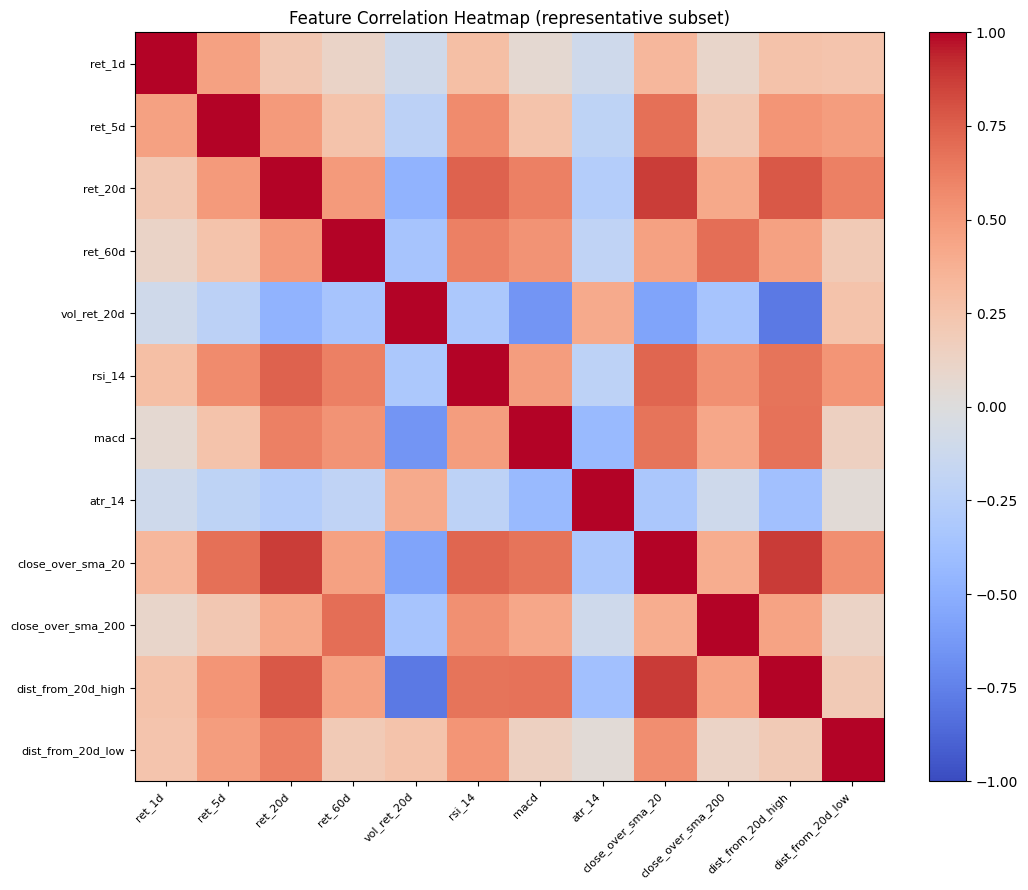

In [30]:
desc_stats = df_prepared[FEATURE_COLS].describe().T
display(desc_stats)

key_features = [f for f in [
    "ret_1d", "ret_5d", "ret_20d", "ret_60d",
    "vol_ret_20d", "rsi_14", "macd", "atr_14",
    "close_over_sma_20", "close_over_sma_200",
    "dist_from_20d_high", "dist_from_20d_low",
] if f in df_prepared.columns]

corr = df_prepared[key_features].corr()

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(len(key_features)))
ax.set_yticks(range(len(key_features)))
ax.set_xticklabels(key_features, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(key_features, fontsize=8)
ax.set_title("Feature Correlation Heatmap (representative subset)", fontsize=12)
plt.tight_layout()
plt.show()


## 11.4 Label Distribution

**Inputs**: `df_prepared` with `label` column.

Compute and display the distribution of `label` values (`buy`, `sell`, `hold`) as:
- An absolute count table.
- A percentage breakdown.
- Optionally a bar chart for visual inspection of class imbalance.

**Outputs**: Label distribution table and optional bar chart.

Label distribution:


,count,pct (%)
buy,1325,34.260000
hold,1412,36.510000
sell,1130,29.220000


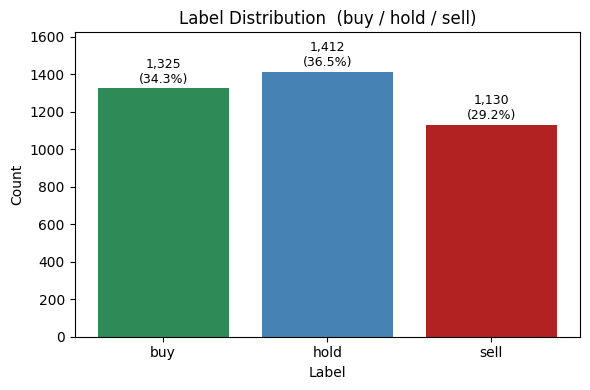

In [31]:
label_order  = ["buy", "hold", "sell"]
label_counts = df_prepared["label"].value_counts().reindex(label_order, fill_value=0)
label_pct    = (label_counts / label_counts.sum() * 100).round(2)

df_label_dist = pd.DataFrame({"count": label_counts, "pct (%)": label_pct})
print("Label distribution:")
display(df_label_dist)

colors = {"buy": "seagreen", "hold": "steelblue", "sell": "firebrick"}
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    label_counts.index,
    label_counts.values,
    color=[colors[l] for l in label_counts.index],
)
ax.set_xlabel("Label")
ax.set_ylabel("Count")
ax.set_title("Label Distribution  (buy / hold / sell)")
for bar, val, pct in zip(bars, label_counts.values, label_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(label_counts) * 0.01,
        f"{val:,}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=9,
    )
ax.set_ylim(0, label_counts.max() * 1.15)
plt.tight_layout()
plt.show()


# 12. Glossary

## 12.1 Raw Column Definitions

**Inputs**: Static definitions from Section 11.1 of the PRD.

Render a table mapping raw column names to their full descriptions. This cell is informational and does not depend on any computed data.

| Column | Full Name | Description |
|---|---|---|
| `symbol` | Ticker Symbol | Ticker from universe CSV, standardised for joins (e.g. `AMZN.US`). |
| `date` | Trading Date | Calendar date of the trading session. |
| `open` | Open Price | Price at market open. |
| `high` | High Price | Highest intraday price. |
| `low` | Low Price | Lowest intraday price. |
| `close` | Close Price | Price at market close. |
| `adj_close` | Adjusted Close | Close price adjusted for splits and dividends. |
| `volume` | Volume | Number of shares traded. |

**Outputs**: Rendered Markdown table (no code cell needed for this sub-section).

## 12.2 Engineered Feature and Target Definitions

**Inputs**: Static definitions from Section 11.2 of the PRD.

Render the full feature glossary table with variable name, full feature name, formula, and description.

| Variable | Full Name | Formula | Description |
|---|---|---|---|
| `ret_1d` | 1-Day Return | `close_t / close_{t-1} - 1` | Daily simple return. |
| `log_ret_1d` | 1-Day Log Return | `ln(close_t / close_{t-1})` | Daily log return. |
| `tr_range` | Intraday Range | `high_t - low_t` | Simple high-low spread. |
| `true_range` | True Range | `max(high_t - low_t, \|high_t - close_{t-1}\|, \|low_t - close_{t-1}\|)` | Wilder's true range accounting for gaps. |
| `ret_5d` | 5-Day Return | `close_t / close_{t-5} - 1` | 5-day price change. |
| `ret_10d` | 10-Day Return | `close_t / close_{t-10} - 1` | 10-day price change. |
| `ret_20d` | 20-Day Return | `close_t / close_{t-20} - 1` | Approx. 1-month price change. |
| `ret_60d` | 60-Day Return | `close_t / close_{t-60} - 1` | Approx. 3-month price change. |
| `log_ret_5d` | 5-Day Log Return | `ln(close_t / close_{t-5})` | 5-day log return. |
| `log_ret_20d` | 20-Day Log Return | `ln(close_t / close_{t-20})` | 20-day log return. |
| `sma_5` | 5-Day SMA | `mean(close, 5)` | Short-term trend. |
| `sma_20` | 20-Day SMA | `mean(close, 20)` | Short-to-medium trend. |
| `sma_50` | 50-Day SMA | `mean(close, 50)` | Medium-term trend. |
| `sma_200` | 200-Day SMA | `mean(close, 200)` | Long-term trend. |
| `close_over_sma_20` | Close / SMA20 | `close_t / sma_20_t` | Relative position to short trend. |
| `close_over_sma_50` | Close / SMA50 | `close_t / sma_50_t` | Relative position to medium trend. |
| `close_over_sma_200` | Close / SMA200 | `close_t / sma_200_t` | Relative position to long trend. |
| `sma_20_slope_5d` | SMA20 5-Day Slope | `sma_20_t / sma_20_{t-5} - 1` | Momentum of the 20-day average. |
| `sma_50_slope_5d` | SMA50 5-Day Slope | `sma_50_t / sma_50_{t-5} - 1` | Momentum of the 50-day average. |
| `vol_ret_5d` | Return Volatility 5D | `std(ret_1d, 5)` | Short-term return volatility. |
| `vol_ret_20d` | Return Volatility 20D | `std(ret_1d, 20)` | Medium-term return volatility. |
| `vol_ret_60d` | Return Volatility 60D | `std(ret_1d, 60)` | Long-term return volatility. |
| `vol_tr_5d` | True Range Volatility 5D | `std(true_range, 5)` | Short-term price range volatility. |
| `vol_tr_20d` | True Range Volatility 20D | `std(true_range, 20)` | Medium-term price range volatility. |
| `value_traded` | Daily Value Traded | `close_t * volume_t` | Proxy for daily liquidity. |
| `vol_ma_20` | Volume MA 20D | `mean(volume, 20)` | Average volume over 20 days. |
| `vol_ma_60` | Volume MA 60D | `mean(volume, 60)` | Average volume over 60 days. |
| `vol_rel_20` | Relative Volume 20D | `volume_t / vol_ma_20_t` | Today's volume relative to 20-day average. |
| `value_traded_ma_20` | Value Traded MA 20D | `mean(value_traded, 20)` | Smoothed liquidity measure. |
| `value_traded_rel_20` | Relative Value Traded 20D | `value_traded_t / value_traded_ma_20_t` | Today's liquidity relative to 20-day average. |
| `rsi_14` | RSI 14 | Wilder RSI of `close`, 14-day | Momentum oscillator (0–100). |
| `macd` | MACD Line | `EMA_12(close) - EMA_26(close)` | Trend-following momentum indicator. |
| `macd_signal` | MACD Signal Line | `EMA_9(macd)` | Smoothed MACD for crossover signals. |
| `macd_hist` | MACD Histogram | `macd - macd_signal` | Distance between MACD and signal. |
| `atr_14` | ATR 14 | Wilder EMA of `true_range`, 14-day | Average true range normalised volatility. |
| `hh_20d` | 20-Day Highest High | `max(high, 20)` | Rolling resistance level. |
| `ll_20d` | 20-Day Lowest Low | `min(low, 20)` | Rolling support level. |
| `dist_from_20d_high` | Distance from 20D High | `(close_t / hh_20d_t) - 1` | Negative: below recent high. |
| `dist_from_20d_low` | Distance from 20D Low | `(close_t / ll_20d_t) - 1` | Positive: above recent low. |
| `fwd_ret_20d` | Forward 20-Day Return | `close_{t+20} / close_t - 1` | Target precursor — future return. |
| `label` | Direction Label | `buy` / `sell` / `hold` | `buy` if `fwd_ret_20d > 0.05`, `sell` if `< -0.05`, else `hold`. |